# Fiery results - epochs

## NB y- and x-axis should be inverted

In [1]:
# imports

import numpy as np
from os.path import join
from matplotlib import pyplot as plt
import pickle
from scipy.stats import norm

In [2]:
from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
                   generate_rel_diagrams, rot, get_clusters

## 0. Helper functions and static variables

In [3]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name


## 1. Get results in the right format

### Generate data for pedestrians

In [4]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]

In [5]:
inst_ped_y = segm_ped_data["inst"]

In [6]:
if False:

    center_ped_y, center_ped_p, _, _ = get_results(results_name = "instance_center", label_name = "centerness", flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("center_results_pedestrains_e12_full.npz", y=center_ped_y, p=center_ped_p)

center_ped_data = np.load("center_results_pedestrains_e12_full.npz")

center_ped_y = segm_ped_data["y"]
center_ped_p = center_ped_data["p"]

In [7]:
segm_ped_y.shape

(5, 5119, 200, 200)

In [8]:
segm_ped_p.shape

(5, 5119, 200, 200)

In [9]:
center_ped_p.shape

(5, 5119, 200, 200)

In [10]:
inst_ped_y.shape

(5, 5119, 200, 200)

## 2. Generate input data from segmentation

In [11]:
nr_future=0
idx = 200

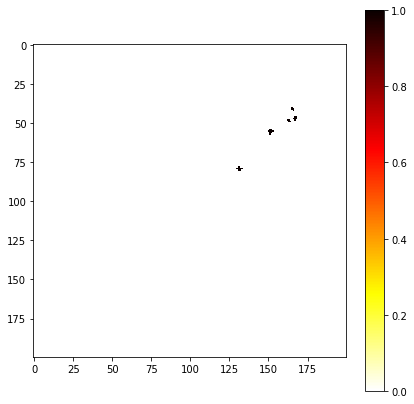

In [12]:
plt.figure(figsize=(7,7))
heatmap = plt.imshow(center_ped_y[nr_future, idx], cmap="hot_r", interpolation='nearest')
plt.colorbar(heatmap)

### Match segmentation and norm-distribution

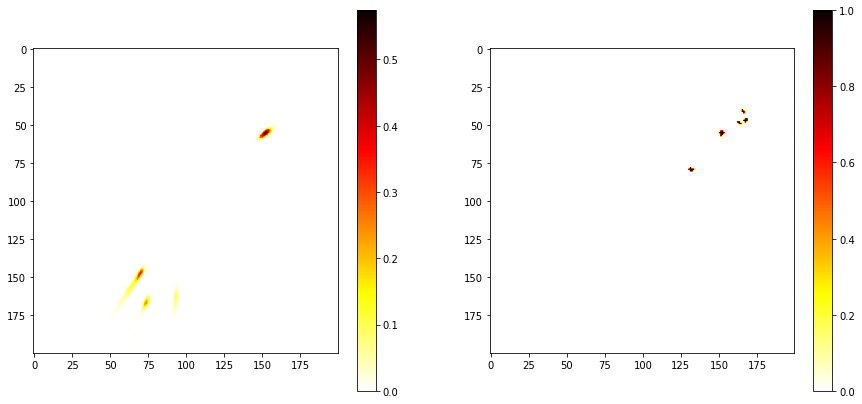

In [13]:
plot_seg(idx, segm_ped_p, segm_ped_y)

## Pixel-wise calibration

In [14]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split


def get_model_cal(p, y, Cal_Fn = IsotonicRegression, nr_future = 0, test_size = 0.8, random_state = 828):

    # 20% for validation (calibration modelling)
    indices_val, indices_test = train_test_split(np.arange(0, p.shape[1]), test_size=test_size, random_state=random_state)

    models = []
    
    masks = [np.ones((200, 200), dtype="bool")]
    
    segm_ped_p_val = p[nr_future, indices_val,]
    segm_ped_y_val = y[nr_future, indices_val,]

    for i, m in enumerate(masks):

        print(i)

        ys_pxl = segm_ped_y_val.reshape(-1) 
        preds_pxl = segm_ped_p_val.reshape(-1)

        print(preds_pxl.shape)
        
        model = Cal_Fn()
        model.fit(preds_pxl, ys_pxl)

        models.append(model)
        
    return models, masks, (indices_val, indices_test)

In [15]:
if True:
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_model_cal(segm_ped_p, segm_ped_y, nr_future = 0, random_state=1001)
    models_cal_c, masks_cal_c, (indices_val_c, _) =  \
        get_model_cal(center_ped_p, center_ped_y, nr_future = 0, random_state=1001)
    
    models_cal_f4, masks_cal_f4, (indices_val_f4, _) = \
        get_model_cal(segm_ped_p, segm_ped_y, nr_future = 4, random_state=1001)
    models_cal_c_f4, masks_cal_c_f4, (indices_val_c_f4, _) =  \
        get_model_cal(center_ped_p, center_ped_y, nr_future = 4, random_state=1001)

0
(40920000,)
0
(40920000,)
0
(40920000,)
0
(40920000,)


In [16]:
if False:
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = 0, random_state=1001)
    models_cal_c, masks_cal_c, (indices_val_c, _) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = 0, random_state=1001)
    
    models_cal_f4, masks_cal_f4, (indices_val_f4, _) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = 4, random_state=1001)
    models_cal_c_f4, masks_cal_c_f4, (indices_val_c_f4, _) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = 4, random_state=1001)

## Location uncertainty

In [17]:
def get_location_quantiles(segm_ped_p, segm_ped_y, center_ped_p, indices_inp, nr_future = 0,
                       models_cal = models_cal, masks_cal = masks_cal, models_cal_c = models_cal_c, 
                       masks_cal_c = masks_cal_c, calib_gmm = False, val_pixels = 40920000):    

    quantiles = []
    indices = []
    center = [99.5, 99.5]

    for count, idx in enumerate(indices_inp):

        if count % 100 == 0:
            print(count)

        # Prep data
            
        segm_cal_full = np.zeros(shape=masks_cal[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            segm_cal_2d[np.isnan(segm_cal_2d)] = 1/val_pixels
            segm_cal_2d = np.clip(segm_cal_2d, 1/val_pixels, 1)
            segm_cal_2d = segm_cal_2d.astype("float64")

            segm_cal_full[mask] = segm_cal_2d[mask]   

        if calib_gmm:
            
            center_cal_full = np.zeros(shape=masks_cal_c[0].shape)
            
            for model_c, mask_c in zip(models_cal_c, masks_cal_c):
                center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
                center_cal_2d = center_cal.reshape(200,200)

                center_cal_2d[np.isnan(center_cal_2d)] = 1/val_pixels
                center_cal_2d = np.clip(center_cal_2d, 1/val_pixels, 1)
                center_cal_2d = center_cal_2d.astype("float64")

                center_cal_full[mask_c] = center_cal_2d[mask_c]

            center_ped_p_new = center_cal_full.copy()
            
            segm_p_new = segm_cal_full.copy()  # Both inputs calibrated
            segm_p_cal_new = segm_cal_full.copy()
            
        else:
            
            center_ped_p_new = center_ped_p[nr_future, idx].copy()
            segm_p_new = segm_ped_p[nr_future, idx].copy()
            segm_p_cal_new = segm_cal_full.copy()
            
        # Get GMMs

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_new, segm_p_cal_new, center_ped_p_new, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        angles = []

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            dist_mean_re = dist.mean - center

            angle = np.rad2deg(np.math.atan2(*dist_mean_re))

            angles.append(angle)

            all_matches.append([[pr], [pr_cal], [dist.mean], [angle], [], [], []])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][4].append(n_cl)
                    all_matches[i][5].append(match_prob)
                    
                    # Match found, rotate axes for norm distribution
                    dist_mean_new = rot(angle) @ dist_mean_re
                    cov_new = rot(angle) @ dist.cov @ rot(angle).T              

                    norm_x = norm(dist_mean_new[0], np.sqrt(cov_new[0,0]))
                    norm_y = norm(dist_mean_new[1], np.sqrt(cov_new[1,1]))

                    ann_xy = np.mean(cl, axis=0)[::-1]  # rotate axes
                    ann_xy_re = ann_xy - center
                    ann_xy_new = rot(angle) @ ann_xy_re

                    qx = norm_x.cdf(ann_xy_new[0])
                    qy = norm_y.cdf(ann_xy_new[1])

                    all_matches[i][6].append(np.array([qx,qy]))


                    # TODO remove

                    dist_old = dist.mean
                    pdf_old = pdfs[i]
                    idx_old = idx

                    #break ## TODO Only check until first match?


        for res in all_matches:
            if len(res[-1]) != 0:
                quantiles.append(res[-1][0])
                indices.append(idx)

        #break
                
    quantiles = np.array(quantiles)
    indices = np.array(indices)
    np.savez("results_all_location_uncertainty%s_n=%i_09_27_22_pw.npz" % (("_cal" if calib_gmm else ""), nr_future), q=quantiles, indices = indices)
    
    return quantiles, indices

In [18]:
quantiles, indices = get_location_quantiles(segm_ped_p, segm_ped_y, center_ped_p, range(0, segm_ped_p.shape[1]), 
                                   nr_future = 0, calib_gmm = False)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [19]:
quantiles2, indices2 = get_location_quantiles(segm_ped_p, segm_ped_y, center_ped_p, range(0, segm_ped_p.shape[1]), 
                                    nr_future = 0, calib_gmm = True)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [20]:
quantiles_f4, indices_f4 = get_location_quantiles(segm_ped_p, segm_ped_y, center_ped_p, range(0, segm_ped_p.shape[1]), 
                                    nr_future = 4, calib_gmm = False,
                                    models_cal = models_cal_f4, masks_cal = masks_cal_f4,
                                    models_cal_c = models_cal_c_f4, 
                                    masks_cal_c = masks_cal_c_f4)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [21]:
quantiles2_f4, indices2_f4 = get_location_quantiles(segm_ped_p, segm_ped_y, center_ped_p, range(0, segm_ped_p.shape[1]), 
                                    nr_future = 4, calib_gmm = True,
                                    models_cal = models_cal_f4, masks_cal = masks_cal_f4,
                                    models_cal_c = models_cal_c_f4, 
                                    masks_cal_c = masks_cal_c_f4)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [19]:
data_np = np.load("results_all_location_uncertainty_n0_09_27_22.npz")
quantiles = data_np["q"]

(array([638.,  85.,  57.,  59.,  41.,  35.,  44.,  46.,  45.,  53.,  44.,
         43.,  52.,  40.,  37.,  59.,  46.,  42.,  53.,  74.,  40.,  52.,
         48.,  51.,  63.,  67.,  70.,  72.,  70.,  70.,  96.,  90.,  77.,
         76., 117., 113., 119., 137., 138., 147., 127., 151., 156., 176.,
        157., 175., 157., 170., 160., 160., 172., 169., 158., 172., 173.,
        157., 197., 153., 147., 150., 155., 141., 112., 115., 124., 119.,
         94.,  82.,  80.,  77.,  78.,  87.,  85.,  54.,  75.,  57.,  57.,
         54.,  67.,  48.,  51.,  51.,  41.,  57.,  46.,  44.,  48.,  36.,
         41.,  42.,  47.,  40.,  43.,  39.,  36.,  44.,  53.,  57.,  77.,
        563.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.

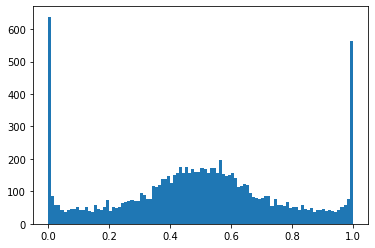

In [20]:
plt.hist(np.array(quantiles)[:, 0], bins = 100)  # X for width

(array([1252.,  222.,  174.,  118.,  111.,  112.,  109.,   90.,   92.,
         109.,   61.,   80.,   69.,   82.,   90.,   86.,   57.,   59.,
          66.,   80.,   72.,   62.,   68.,   75.,   84.,   72.,   73.,
          72.,   94.,   68.,   63.,   77.,   76.,   72.,   77.,   70.,
          73.,   79.,   59.,   77.,   66.,   67.,   76.,   71.,   71.,
          74.,   74.,   67.,   63.,   68.,   82.,   82.,   69.,   82.,
          74.,   85.,   71.,   83.,   73.,   80.,   71.,   64.,   49.,
          67.,   69.,   51.,   77.,   78.,   67.,   63.,   73.,   57.,
          60.,   62.,   69.,   55.,   65.,   65.,   61.,   56.,   53.,
          69.,   57.,   70.,   69.,   71.,   61.,   77.,   68.,   82.,
          78.,   73.,   93.,   83.,   82.,  111.,  103.,  146.,  189.,
         786.]),
 array([1.57943558e-182, 1.00000000e-002, 2.00000000e-002, 3.00000000e-002,
        4.00000000e-002, 5.00000000e-002, 6.00000000e-002, 7.00000000e-002,
        8.00000000e-002, 9.00000000e-002, 1.000000

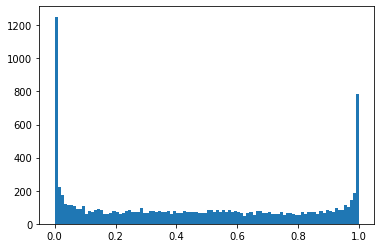

In [21]:
plt.hist(np.array(quantiles)[:, 1], bins = 100)  # y for distance

In [22]:
def rel_diag_quantiles(data, l = 100):
    qs = np.linspace(1/l, 1, l)
    plt.plot(qs, np.quantile(data, qs))
    plt.gca().set_aspect('equal', 'box')
    plt.title("QQ plot")

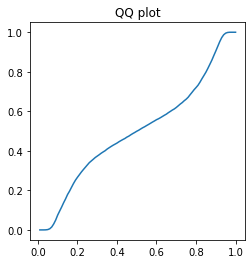

In [23]:
rel_diag_quantiles(np.array(quantiles)[:, 0])  # X for width

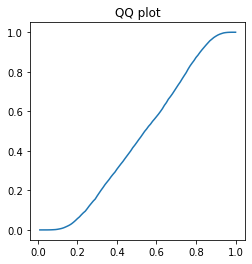

In [24]:
rel_diag_quantiles(np.array(quantiles)[:, 1])  # Y for distance

### For calibrated data

In [27]:
if False:

    quantiles_cal = []
    center = [99.5, 99.5]

    for count, idx in enumerate(indices_test):

        if count % 100 == 0:
            print(count)
        
        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)
            segm_cal_full[mask] = segm_cal_2d[mask]

        for model_c, mask_c in zip(models_cal_c, masks_cal_c):
            center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
            center_cal_2d = center_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            center_cal_full[mask_c] = center_cal_2d[mask_c]

        center_p_cal = center_cal_full.copy()
        #segm_p_new = segm_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()
        #center_ped_p_new = center_ped_p[nr_future, idx].copy()

        # TODO center_ped_p_cal?
        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_cal_new, segm_p_cal_new, center_p_cal, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[0, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        angles = []

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            dist_mean_re = dist.mean - center

            #print(dist_mean_re)

            angle = np.rad2deg(np.math.atan2(*dist_mean_re))
            #print(dist.mean)
            #print("Angle:", angle)

            angles.append(angle)

            all_matches.append([[pr], [pr_cal], [dist.mean], [angle], [], [], []])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][4].append(n_cl)
                    all_matches[i][5].append(match_prob)
                    #all_matches[i][4].append(dist.mean)

                    # Match found, rotate axes for norm distribution
                    dist_mean_new = rot(angle) @ dist_mean_re
                    cov_new = rot(angle) @ dist.cov @ rot(angle).T


                    #print(n_cl)
                    #print(cov_new)                

                    norm_x = norm(dist_mean_new[0], np.sqrt(cov_new[0,0]))
                    norm_y = norm(dist_mean_new[1], np.sqrt(cov_new[1,1]))

                    ann_xy = np.mean(cl, axis=0)[::-1]  # rotate axes
                    ann_xy_re = ann_xy - center
                    ann_xy_new = rot(angle) @ ann_xy_re

                    # TODO rotate the ann_xy and move according to zero (-99.5, -99.5)


                    qx = norm_x.cdf(ann_xy_new[0])
                    qy = norm_y.cdf(ann_xy_new[1])

                    all_matches[i][6].append(np.array([qx,qy]))


                    # TODO remove

                    dist_old = dist.mean
                    pdf_old = pdfs[i]
                    idx_old = idx

                    #break ## TODO Only check until first match?


        for res in all_matches:
            if len(res[-1]) != 0:
                quantiles_cal.append(res[-1][0])

        #break
        
    quantiles_cal = np.array(quantiles_cal)
    np.savez("results_location_uncertainty_cal_09_23_22.npz", q=quantiles_cal)        

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000


In [28]:
data_np = np.load("results_location_uncertainty_cal_09_23_22.npz")
quantiles_cal = data_np["q"]

(array([514.,  67.,  63.,  40.,  33.,  32.,  41.,  40.,  32.,  32.,  52.,
         49.,  44.,  48.,  44.,  34.,  40.,  38.,  39.,  61.,  54.,  50.,
         43.,  52.,  51.,  55.,  47.,  56.,  61.,  59.,  49.,  67.,  69.,
         66.,  62.,  67.,  79.,  96.,  69.,  91.,  94.,  95., 102., 101.,
        104.,  99.,  80.,  80.,  80., 101.,  81., 103., 110.,  90.,  85.,
        100.,  99., 111.,  93., 104.,  94.,  81.,  80.,  72.,  65.,  68.,
         64.,  63.,  63.,  60.,  50.,  58.,  46.,  42.,  46.,  51.,  45.,
         45.,  44.,  48.,  47.,  49.,  62.,  46.,  48.,  34.,  47.,  40.,
         34.,  29.,  38.,  41.,  41.,  31.,  42.,  30.,  36.,  51.,  71.,
        432.]),
 array([9.94555552e-133, 1.00000000e-002, 2.00000000e-002, 3.00000000e-002,
        4.00000000e-002, 5.00000000e-002, 6.00000000e-002, 7.00000000e-002,
        8.00000000e-002, 9.00000000e-002, 1.00000000e-001, 1.10000000e-001,
        1.20000000e-001, 1.30000000e-001, 1.40000000e-001, 1.50000000e-001,
        1.6000

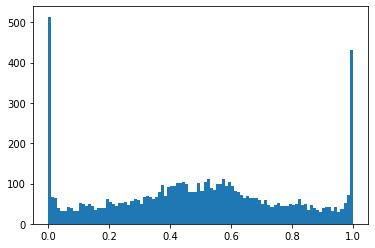

In [29]:
plt.hist(np.array(quantiles_cal)[:, 0], bins = 100)

(array([741., 108.,  95.,  85.,  71.,  65.,  58.,  43.,  55.,  59.,  46.,
         54.,  56.,  51.,  46.,  51.,  43.,  61.,  53.,  44.,  52.,  47.,
         50.,  56.,  62.,  56.,  64.,  51.,  61.,  64.,  52.,  65.,  69.,
         55.,  45.,  47.,  65.,  46.,  61.,  56.,  68.,  58.,  67.,  51.,
         51.,  67.,  64.,  48.,  45.,  51.,  56.,  68.,  62.,  65.,  59.,
         59.,  60.,  58.,  63.,  70.,  72.,  46.,  39.,  56.,  74.,  68.,
         43.,  44.,  58.,  69.,  50.,  45.,  42.,  55.,  51.,  51.,  53.,
         60.,  50.,  56.,  43.,  51.,  54.,  53.,  47.,  48.,  52.,  54.,
         51.,  56.,  67.,  55.,  64.,  71.,  70.,  79.,  63.,  94., 111.,
        468.]),
 array([5.77655674e-74, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.7000

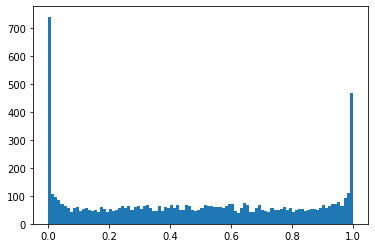

In [30]:
plt.hist(np.array(quantiles_cal)[:, 1], bins = 100)

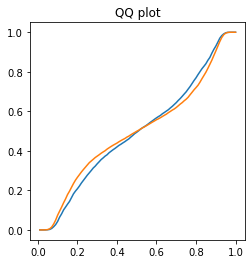

In [31]:
rel_diag_quantiles(np.array(quantiles_cal)[:, 0])  # X for width
rel_diag_quantiles(np.array(quantiles)[:, 0])  # X for width

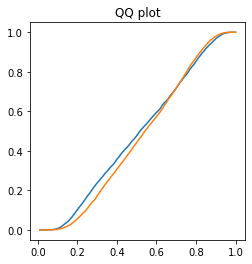

In [32]:
rel_diag_quantiles(np.array(quantiles_cal)[:, 1])  # Y for distance
rel_diag_quantiles(np.array(quantiles)[:, 1])  # Y for width

## Debug

In [ ]:
x, y = np.mgrid[0:200:1, 0:200:1]
pos = np.dstack((x, y))

fig2 = plt.figure()
ax2 = plt.gca()
#ax2 = fig2.add_subplot(111)
ax2.contourf(x, y, np.clip(np.sum([pdf_old], axis=0), 0, 0.01))  # For some reason 10x difference with segm mapping
#ax2.set_ylim([0,200])
plt.gca().invert_yaxis()

plt.scatter(*ann_xy, color = "white", s = 15, marker = "x")
plt.scatter(*dist_old, color = "red", s = 15, marker = "x")
plt.grid()
plt.title("Idx: %i" % idx_old)
ax2.set_aspect('equal', 'box')

In [ ]:
ann_xy

In [ ]:
ann_xy_new

In [ ]:
dist_mean_new

In [ ]:
cov_new

In [ ]:
pdfs_new_angle = []

x, y = np.mgrid[-100:100:1, -100:100:1]
pos = np.dstack((x, y))

#cov_new = rot(angles[j]) @ dists[j].cov @ rot(angles[j])

rv = multivariate_normal(dist_mean_new, cov_new)


thr = rv.pdf([rv.mean[0] + 3*np.sqrt(rv.cov[0,0]), rv.mean[1] + 3*np.sqrt(rv.cov[1,1])])
pdfs_new_angle.append(rv.pdf(pos))

masks = []
segm_preds = []
#distributions

fig2 = plt.figure()
ax2 = plt.gca()
#ax2 = fig2.add_subplot(111)
ax2.contourf(x, y, np.clip(np.sum(pdfs_new_angle, axis=0), 0, 1))  # For some reason 10x difference with segm mapping
plt.scatter(*ann_xy_new, color = "white", s = 15, marker = "x")
plt.scatter(*dist_mean_new, color = "red", s = 15, marker = "x")

#ax2.set_ylim([0,200])
plt.gca().invert_xaxis()
plt.title("Idx: %i" % idx_old)
plt.grid()
ax2.set_aspect('equal', 'box')

In [ ]:
plot_seg(113, segm_ped_p, segm_ped_y)

In [ ]:
rv.pdf(ann_xy_new)

In [ ]:
qx

In [ ]:
qy

In [ ]:
norm_x.cdf(ann_xy_new[0])

In [ ]:
ann_xy_new

In [ ]:
norm()

In [ ]:
multivariate_normal()

In [ ]:
norm_y.std()

In [ ]:
cov_new

In [ ]:
norm_y.cdf(ann_xy_new[1])